# 03 — Old Dataset Feature Engineering

This notebook prepares `sensor_clean_model.csv` for the old-dataset model.

## Goal
Create robust time-series / sensor-health features without changing the cleaned source data.

### Modeling direction
The old dataset contains:
- 220,320 minute-level observations
- 51 usable sensor columns (`sensor_15` was removed during cleaning)
- `machine_status`: `NORMAL`, `RECOVERING`, `BROKEN`
- only 7 `BROKEN` observations

Because the `BROKEN` class is extremely small, this pipeline focuses on **sensor anomaly / machine-health modeling** rather than a conventional 3-class failure classifier.

The engineered output will be saved as:

`ml/data/processed/sensor_features.csv`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path("..")
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"

INPUT_FILE = PROCESSED_DATA_DIR / "sensor_clean_model.csv"
OUTPUT_FILE = PROCESSED_DATA_DIR / "sensor_features.csv"

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_FILE)


Input: ..\data\processed\sensor_clean_model.csv
Output: ..\data\processed\sensor_features.csv


In [2]:
df = pd.read_csv(INPUT_FILE, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
print("Time range:", df["timestamp"].min(), "→", df["timestamp"].max())
print("\nMachine status:")
print(df["machine_status"].value_counts(dropna=False))


Shape: (220320, 104)
Time range: 2018-04-01 00:00:00 → 2018-08-31 23:59:00

Machine status:
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


In [3]:
sensor_columns = [
    c for c in df.columns
    if c.startswith("sensor_") and not c.endswith("_missing")
]

missing_indicator_columns = [
    c for c in df.columns
    if c.startswith("sensor_") and c.endswith("_missing")
]

print("Sensor columns:", len(sensor_columns))
print("Missing-indicator columns:", len(missing_indicator_columns))
print("Example sensors:", sensor_columns[:10])


Sensor columns: 51
Missing-indicator columns: 51
Example sensors: ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09']


## 1. Select informative sensors

We do not manually assign physical meanings to `sensor_XX` because the dataset documentation does not provide those mappings.

For feature engineering, the sensors are ranked by variability during `NORMAL` operation. The most variable sensors are used for detailed temporal features, while aggregate statistics summarize the complete sensor set.


In [4]:
normal_df = df.loc[df["machine_status"] == "NORMAL", sensor_columns]

sensor_std = normal_df.std(numeric_only=True).sort_values(ascending=False)

TOP_N_SENSORS = 12
top_sensors = sensor_std.head(TOP_N_SENSORS).index.tolist()

print("Top sensors selected for detailed temporal features:")
print(top_sensors)

display(sensor_std.head(20).to_frame("std_during_normal"))


Top sensors selected for detailed temporal features:
['sensor_28', 'sensor_23', 'sensor_36', 'sensor_31', 'sensor_32', 'sensor_26', 'sensor_21', 'sensor_29', 'sensor_25', 'sensor_19', 'sensor_30', 'sensor_24']


,std_during_normal
sensor_28,315.728937
sensor_23,299.415218
sensor_36,293.541938
sensor_31,285.363986
sensor_32,261.679772
sensor_26,253.202199
sensor_21,233.152249
sensor_29,230.409871
sensor_25,227.093641
sensor_19,205.060263


In [5]:
# Aggregate sensor state at each timestamp.
# pandas mean/std/min/max skip NaN values, which is useful because long missing periods
# were intentionally retained in sensor_clean_model.csv.

df_features = df[["timestamp", "machine_status"]].copy()

sensor_values = df[sensor_columns]

df_features["sensor_mean"] = sensor_values.mean(axis=1)
df_features["sensor_std"] = sensor_values.std(axis=1)
df_features["sensor_min"] = sensor_values.min(axis=1)
df_features["sensor_max"] = sensor_values.max(axis=1)
df_features["sensor_range"] = df_features["sensor_max"] - df_features["sensor_min"]

# Overall missingness at each timestamp.
df_features["missing_sensor_ratio"] = df[missing_indicator_columns].mean(axis=1)

print(df_features.head())


            timestamp machine_status  sensor_mean  sensor_std  sensor_min  \
0 2018-04-01 00:00:00         NORMAL   278.944728  296.112519    1.681353   
1 2018-04-01 00:01:00         NORMAL   278.944728  296.112519    1.681353   
2 2018-04-01 00:02:00         NORMAL   282.829332  300.711329    1.708474   
3 2018-04-01 00:03:00         NORMAL   283.202554  300.749374    1.579427   
4 2018-04-01 00:04:00         NORMAL   282.038153  300.240543    1.683831   

   sensor_max  sensor_range  missing_sensor_ratio  
0    975.9409    974.259547                   0.0  
1    975.9409    974.259547                   0.0  
2    982.7342    981.025726                   0.0  
3    977.7520    976.172573                   0.0  
4    979.5755    977.891669                   0.0  


In [6]:
# Add the selected raw sensor values.
for sensor in top_sensors:
    df_features[sensor] = df[sensor].values

# First-order change captures sudden sensor movement.
for sensor in top_sensors:
    df_features[f"{sensor}_diff"] = df[sensor].diff()

# Temporal statistics use only the current row and previous observations.
# No centered rolling windows are used, so future observations are not introduced.
ROLLING_WINDOWS = [30, 120]  # minutes

for window in ROLLING_WINDOWS:
    df_features[f"sensor_mean_rollmean_{window}m"] = (
        df_features["sensor_mean"].rolling(window=window, min_periods=5).mean()
    )
    df_features[f"sensor_mean_rollstd_{window}m"] = (
        df_features["sensor_mean"].rolling(window=window, min_periods=5).std()
    )
    df_features[f"sensor_std_rollmean_{window}m"] = (
        df_features["sensor_std"].rolling(window=window, min_periods=5).mean()
    )

# Change in the aggregate sensor state.
df_features["sensor_mean_diff"] = df_features["sensor_mean"].diff()
df_features["sensor_std_diff"] = df_features["sensor_std"].diff()

print("Engineered shape:", df_features.shape)
display(df_features.head())


Engineered shape: (220320, 40)


,timestamp,machine_status,sensor_mean,sensor_std,sensor_min,sensor_max,sensor_range,missing_sensor_ratio,sensor_28,sensor_23,sensor_36,sensor_31,sensor_32,sensor_26,sensor_21,sensor_29,sensor_25,sensor_19,sensor_30,sensor_24,sensor_28_diff,sensor_23_diff,sensor_36_diff,sensor_31_diff,sensor_32_diff,sensor_26_diff,sensor_21_diff,sensor_29_diff,sensor_25_diff,sensor_19_diff,sensor_30_diff,sensor_24_diff,sensor_mean_rollmean_30m,sensor_mean_rollstd_30m,sensor_std_rollmean_30m,sensor_mean_rollmean_120m,sensor_mean_rollstd_120m,sensor_std_rollmean_120m,sensor_mean_diff,sensor_std_diff
0,2018-04-01 00:00:00,NORMAL,278.944728,296.112519,1.681353,975.9409,974.259547,0.0,785.1935,975.9409,195.0655,682.8125,680.4416,848.0708,880.0001,684.9443,741.7151,665.3993,594.4445,627.6740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-04-01 00:01:00,NORMAL,278.944728,296.112519,1.681353,975.9409,974.259547,0.0,785.1935,975.9409,195.0655,682.8125,680.4416,848.0708,880.0001,684.9443,741.7151,665.3993,594.4445,627.6740,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
2,2018-04-01 00:02:00,NORMAL,282.829332,300.711329,1.708474,982.7342,981.025726,0.0,778.5734,982.7342,200.9694,721.8750,694.7721,849.8997,880.4237,715.6266,740.8031,666.2234,661.5740,631.1326,-6.6201,6.7933,5.9039,39.0625,14.3305,1.8289,0.4236,30.6823,-0.9120,0.8241,67.1295,3.4586,NaN,NaN,NaN,NaN,NaN,NaN,3.884603,4.598809
3,2018-04-01 00:03:00,NORMAL,283.202554,300.749374,1.579427,977.7520,976.172573,0.0,779.5091,977.7520,193.1689,754.6875,683.3831,847.7579,878.8917,690.4011,739.2722,666.0114,686.1111,625.4076,0.9357,-4.9822,-7.8005,32.8125,-11.3890,-2.1418,-1.5320,-25.2255,-1.5309,-0.2120,24.5371,-5.7250,NaN,NaN,NaN,NaN,NaN,NaN,0.373223,0.038045
4,2018-04-01 00:04:00,NORMAL,282.038153,300.240543,1.683831,979.5755,977.891669,0.0,785.2307,979.5755,193.8770,766.1458,702.4431,846.9182,882.5874,704.6937,737.6033,663.2111,631.4814,627.1830,5.7216,1.8235,0.7081,11.4583,19.0600,-0.8397,3.6957,14.2926,-1.6689,-2.8003,-54.6297,1.7754,281.191899,2.094016,298.785257,281.191899,2.094016,298.785257,-1.164402,-0.508831


## 2. Validate the engineered data

Missing values are intentionally allowed to remain at this stage.

The model-training notebook will perform imputation **inside the modeling pipeline**, which prevents preprocessing leakage and keeps training/inference behavior consistent.


In [7]:
feature_columns = [
    c for c in df_features.columns
    if c not in ["timestamp", "machine_status"]
]

print("Number of model features:", len(feature_columns))
print("\nMissing values in engineered features:")
display(
    df_features[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("missing_count")
)

print("\nInfinite values:", np.isinf(df_features[feature_columns].select_dtypes(include=np.number)).sum().sum())


Number of model features: 38

Missing values in engineered features:


,missing_count
sensor_30_diff,121
sensor_30,119
sensor_mean_rollstd_30m,4
sensor_mean_rollmean_30m,4
sensor_std_rollmean_120m,4
sensor_mean_rollstd_120m,4
sensor_std_rollmean_30m,4
sensor_mean_rollmean_120m,4
sensor_26_diff,1
sensor_21_diff,1



Infinite values: 0


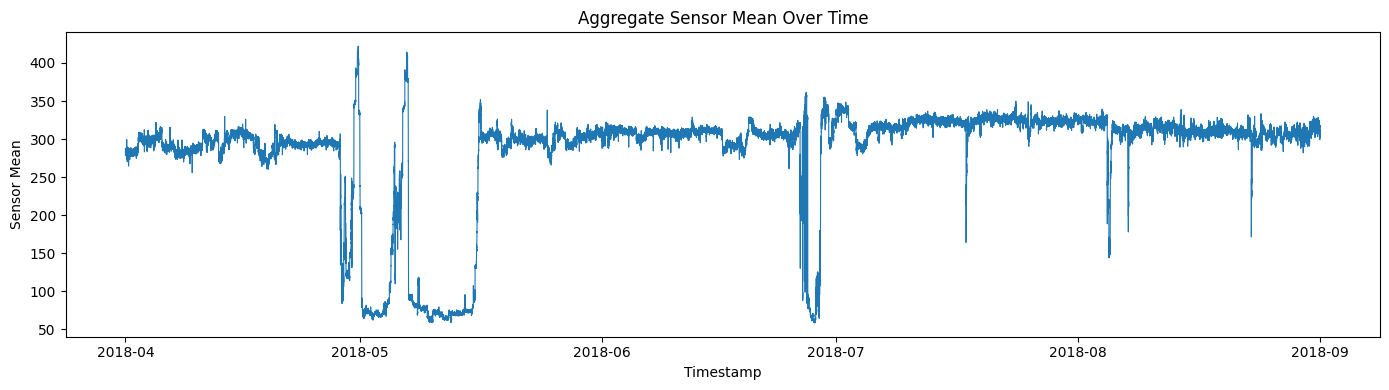

In [8]:
# Quick view of the aggregate sensor signal.
plt.figure(figsize=(14, 4))
plt.plot(df_features["timestamp"], df_features["sensor_mean"], linewidth=0.8)
plt.title("Aggregate Sensor Mean Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Mean")
plt.tight_layout()
plt.show()


In [9]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
df_features.to_csv(OUTPUT_FILE, index=False)

print(f"Saved: {OUTPUT_FILE}")
print("Final shape:", df_features.shape)


Saved: ..\data\processed\sensor_features.csv
Final shape: (220320, 40)
